### Topic
Iris class prediction

### Model
Losigtic Regression - Multi-Class

### Data
sklearn - datasets - load_iris

In [82]:
# load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

from sklearn.datasets import load_iris
iris = load_iris()

In [83]:
# check feature and label
print("feature names : ", iris["feature_names"])
print("target  names : ", iris["target_names"])

print("data[0] : ", iris["data"][0])
print("target[:] : ", iris["target"][:])

feature names :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target  names :  ['setosa' 'versicolor' 'virginica']
data[0] :  [5.1 3.5 1.4 0.2]
target[:] :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [84]:
# data EDA
data, target = iris["data"], iris["target"]
df = pd.DataFrame(data, columns=iris["feature_names"])
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [85]:
pd.Series(target).value_counts()

,count
0,50
1,50
2,50


In [86]:
# Split data
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(
    data, target, train_size=0.7, random_state=42
)
print("train size : ", len(train_data))
print("test  size : ", len(test_data))
print(pd.Series(train_target).value_counts())

train size :  105
test  size :  45
1    37
2    37
0    31
Name: count, dtype: int64


In [87]:
# stratify option for the correct ratio
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split(
    data, target, train_size=0.7, random_state=42, stratify=target
)
print("train size : ", len(train_data))
print("test  size : ", len(test_data))
print(pd.Series(train_target).value_counts())

train size :  105
test  size :  45
1    35
0    35
2    35
Name: count, dtype: int64


### Multiclass Logistic Regression

1. one vs rest

2. multinomial

Text(0, 0.5, 'Sepal width')

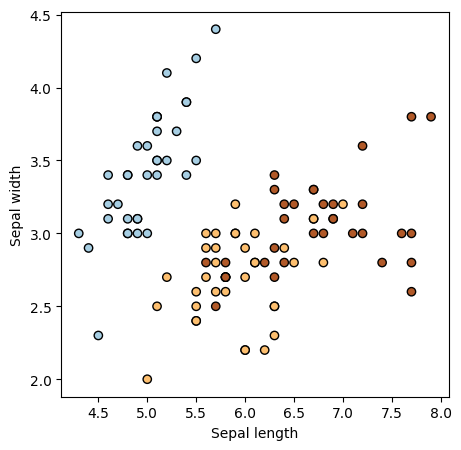

In [88]:
# visualization with the first and second features
X = train_data[:,:2]
plt.figure(1, figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=train_target, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")

In [89]:
# 1. one vs rest - two features
# Load and train the model
from sklearn.linear_model import LogisticRegression
ovr_logit = LogisticRegression(multi_class="ovr")
ovr_logit.fit(X, train_target)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

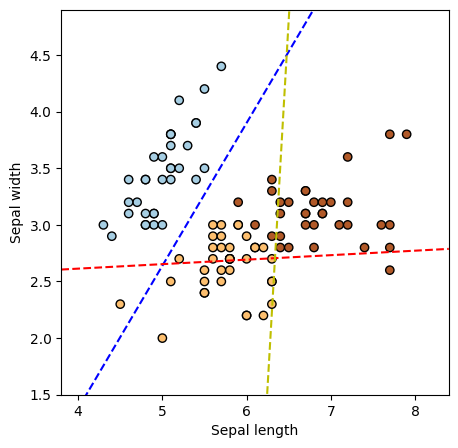

In [90]:

# plot two features
plt.figure(1, figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=ovr_logit.predict(X), edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
coef = ovr_logit.coef_
intercept = ovr_logit.intercept_
def plot_hyperplane(c, color) :
  def line(x0):
    return (-1*(x0 * coef[c,0]) - intercept[c]) / coef[c,1]
  plt.plot([x_min, x_max], [line(x_min),line(x_max)], ls="--", color=color)

for i, color in zip(ovr_logit.classes_, "bry") :
  plot_hyperplane(i, color)


In [91]:
# 2. Multinomial  - two features
multi_logit = LogisticRegression(multi_class="multinomial")
multi_logit.fit(X, train_target)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial')

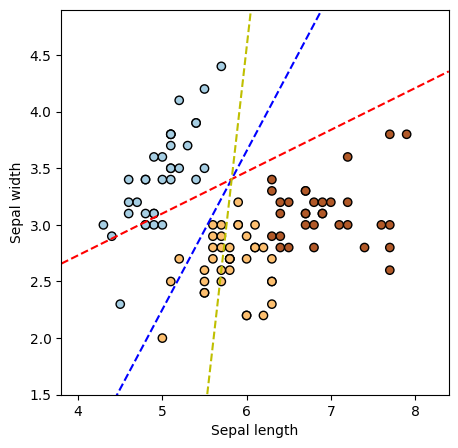

In [92]:
# plot two features
x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

plt.figure(1, figsize=(5, 5))

plt.scatter(X[:, 0], X[:, 1], c=multi_logit.predict(X), edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

coef = multi_logit.coef_
intercept = multi_logit.intercept_

def plot_hyperplane(c, color):
    def line(x0):
        return (-(x0 * coef[c, 0]) - intercept[c]) / coef[c, 1]
    plt.plot([x_min, x_max], [line(x_min), line(x_max)],
             ls="--", color=color)

for i, color in zip(multi_logit.classes_, "bry"):
    plot_hyperplane(i, color)

In [93]:
# Repeat with the full features

# 1. one vs rest - full features
ovr_logit = LogisticRegression(multi_class="ovr")
ovr_logit.fit(train_data, train_target)
# 2. Multinomial - full features
multi_logit = LogisticRegression()
multi_logit.fit(train_data, train_target)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [94]:
# Evaluation
ovr_train_pred = ovr_logit.predict(train_data)
ovr_test_pred = ovr_logit.predict(test_data)
multi_train_pred = multi_logit.predict(train_data)
multi_test_pred = multi_logit.predict(test_data)

from sklearn.metrics import accuracy_score
ovr_train_acc = accuracy_score(train_target, ovr_train_pred)
ovr_test_acc = accuracy_score(test_target, ovr_test_pred)
multi_train_acc = accuracy_score(train_target, multi_train_pred)
multi_test_acc = accuracy_score(test_target, multi_test_pred)

print(f"ovr train acc : {ovr_train_acc:.4f}")
print(f"ovr test  acc : {ovr_test_acc:.4f}")
print(f"mul train acc : {multi_train_acc:.4f}")
print(f"mul test  acc : {multi_test_acc:.4f}")


ovr train acc : 0.9619
ovr test  acc : 0.8889
mul train acc : 0.9714
mul test  acc : 0.9333


### Summary

 - One vs Rest

 Train Acc : 96.19 %

 Test  Acc : 88.89 %

 - Multinomial

 Train Acc : 97.14 %

 Test  Acc : 93.33 %